# Unit 5: 频域分析与特征提取

## 学习目标
- 理解 FFT 和功率谱密度（PSD）
- 掌握各频段（δ, θ, α, β, γ）的功率计算
- 学习统计特征（均值、标准差、RMS）
- 构建特征向量用于后续 ML 分析
- 对比不同通道的频谱特征

MSE（Mean Squared Error，均方误差）  

* 概念：对每个误差（预测值减去真实值）的平方取平均。
* 公式：
$ \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $


In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
# 负责采集数据
from brainflow.board_shim import (
    BoardShim, 
    BrainFlowInputParams, 
    BoardIds
)
# 负责数据处理
from brainflow.data_filter import (
    DataFilter, 
    FilterTypes, 
    AggOperations,
    DetrendOperations, 
    WindowOperations, 
    NoiseTypes
)

# 设置中文字体
if os.name == 'nt':
    plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
elif os.name == 'posix': # macos 或 linux
    plt.rcParams['font.sans-serif'] = ['PingFang SC', 'Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

print("模块导入完成")

模块导入完成
模块导入完成


## 5.1 准备数据并预处理

先采集数据并执行标准预处理流水线。

In [2]:
# 采集数据
board = BoardShim(BoardIds.SYNTHETIC_BOARD, BrainFlowInputParams())
board.prepare_session()
board.start_stream()
time.sleep(15)
data = board.get_board_data()
board.stop_stream()
board.release_session()

descr = BoardShim.get_board_descr(BoardIds.SYNTHETIC_BOARD)
eeg_channels = descr['eeg_channels']
eeg_names = BoardShim.get_eeg_names(BoardIds.SYNTHETIC_BOARD)
sampling_rate = descr['sampling_rate']

print(f"采集了 {data.shape[1]} 个样本，{sampling_rate} Hz，约 {data.shape[1]/sampling_rate:.1f} 秒")


/Users/usst_ziyi/Programs/trae/Brain/openbci-5/.venv/lib/python3.10/site-packages/brainflow/board_shim.py:185: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-16 17:59:35.401] [board_logger] [info] incoming json: {
    "file": "",
    "file_anc": "",
    "file_aux": "",
    "ip_address": "",
    "ip_address_anc": "",
    "ip_address_aux": "",
    "ip_port": 0,
    "ip_port_anc": 0,
    "ip_port_aux": 0,
    "ip_protocol": 0,
    "mac_address": "",
    "master_board": -100,
    "other_info": "",
    "serial_number": "",
    "serial_port": "",
    "timeout": 0
}


采集了 3752 个样本，250 Hz，约 15.0 秒


In [ ]:
# 标准预处理
def preprocess_eeg(data, ch_idx, sr):
    signal = data[ch_idx].copy().astype(np.float64)
    DataFilter.detrend(signal, DetrendOperations.LINEAR.value)
    DataFilter.perform_bandpass(signal, sr, 22.5, 45.0, 4,
                                 FilterTypes.BUTTERWORTH.value, 0)
    DataFilter.perform_bandstop(signal, sr, 49.5, 50.5, 4,
                                 FilterTypes.BUTTERWORTH.value, 0)
    return signal

eeg_data = data[eeg_channels, :].copy().astype(np.float64)
processed_eeg = np.array([preprocess_eeg(data, ch, sampling_rate) 
                           for ch in eeg_channels])
print(f"预处理完成，形状: {processed_eeg.shape}")

预处理完成，形状: (16, 3752)


## 5.2 FFT 与 PSD 基础

**FFT（快速傅里叶变换）**：将时域信号转换到频域。

**PSD（功率谱密度）**：描述信号功率在频率上的分布。BrainFlow 支持 Welch 方法。

`DataFilter.get_psd_welch(data, nfft, overlap, sampling_rate, window)`
- data: 一维数组，一个通道的信号数据
- nfft: FFT 大小，必须是 2 的幂次
- overlap: 重叠大小，必须是 nfft 的整数倍
- sampling_rate: 采样率
- window: 窗口函数，可选，默认 Blackman-Harris
- 返回 `(amplitudes, frequencies)` 两个数组


NFFT: 256
PSD 振幅长度: 129
频率分辨率: 0.977 Hz


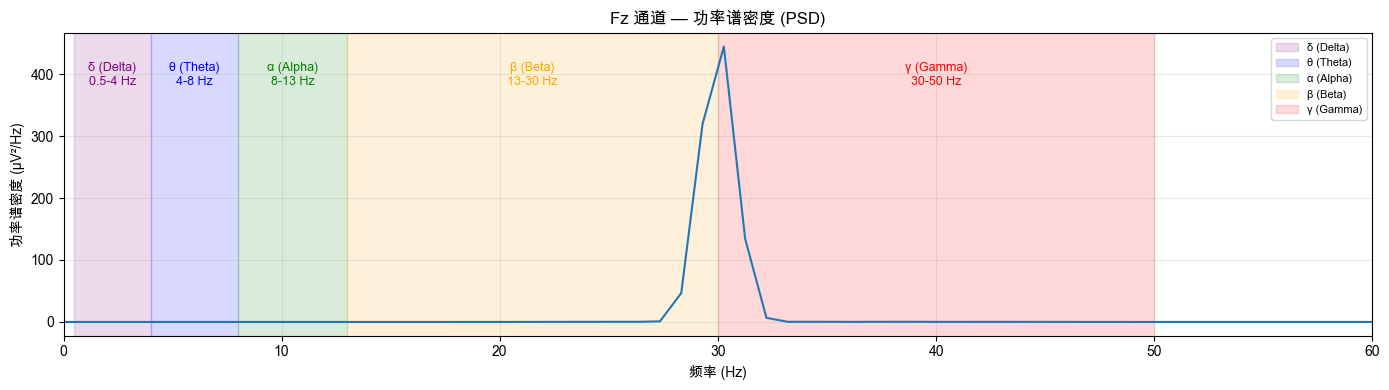

In [ ]:
# 计算 FO7 通道的 PSD
ch_data = processed_eeg[5, :]

# Welch 方法计算 PSD
# 计算一个接近采样率的 2 的幂次方数，用于 FFT 运算
nfft = DataFilter.get_nearest_power_of_two(sampling_rate)
# BrainFlow 的 DataFilter.get_psd_welch 只能处理一维数组，也就是单通道数据。
psd_ampl, psd_freq = DataFilter.get_psd_welch(
    data=ch_data, 
    nfft=nfft,  # FFT 窗口大小，必须是 2 的幂次方
    overlap=nfft // 2, # 相邻窗口重叠点数，这里设置为一半，典型做法可减少方差
    sampling_rate=sampling_rate,
    window=WindowOperations.BLACKMAN_HARRIS.value # Blackman-Harris 窗，可以减少频谱泄漏
)

print(f"NFFT: {nfft}")
print(f"PSD 振幅长度: {len(psd_ampl)}")
print(f"频率分辨率: {psd_freq[1] - psd_freq[0]:.3f} Hz")

# 绘制 PSD
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(psd_freq[:len(psd_freq)//2], psd_ampl[:len(psd_ampl)//2])
ax.set_xlabel('频率 (Hz)')
ax.set_ylabel('功率谱密度 (μV²/Hz)')
ax.set_title('Fz 通道 — 功率谱密度 (PSD)')
ax.grid(True, alpha=0.3)

# 标注频带
bands = [
    (0.5, 4, 'δ (Delta)', 'purple'),
    (4, 8, 'θ (Theta)', 'blue'),
    (8, 13, 'α (Alpha)', 'green'),
    (13, 30, 'β (Beta)', 'orange'),
    (30, 50, 'γ (Gamma)', 'red'),
]
for low, high, name, color in bands:
    ax.axvspan(low, high, alpha=0.15, color=color, label=name)
    # 在频带中心位置添加频率名称文本，并在下方显示频率范围
    center_freq = (low + high) / 2
    ax.text(center_freq, ax.get_ylim()[1] * 0.9, f'{name}\n{low}-{high} Hz', 
            ha='center', va='top', fontsize=9, color=color, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 60)
plt.tight_layout()
plt.show()

## 5.3 各通道 PSD 对比

不同脑区的 EEG 信号有不同的频谱特征。

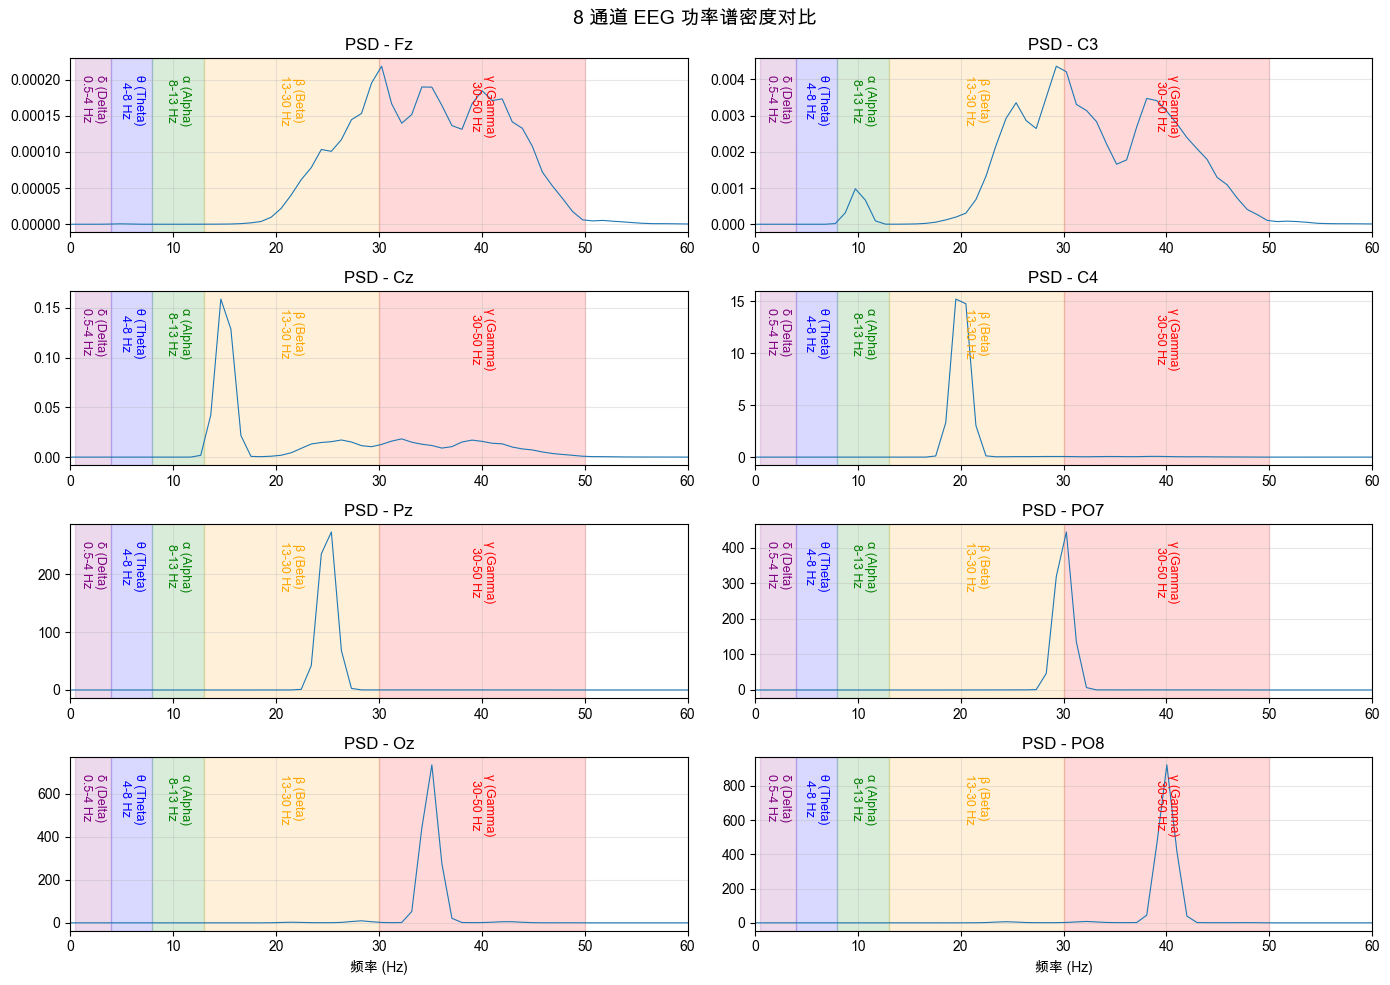

In [49]:
# 绘制所有 EEG 通道的 PSD 对比
fig, axes = plt.subplots(4, 2, figsize=(14, 10))
axes = axes.flatten()

nfft = DataFilter.get_nearest_power_of_two(sampling_rate)

for i in range(8):
    # BrainFlow 的 DataFilter.get_psd_welch 只能处理一维数组，也就是单通道数据。
    ampl, freq = DataFilter.get_psd_welch(
        processed_eeg[i, :], nfft, nfft // 2, sampling_rate,
        WindowOperations.BLACKMAN_HARRIS.value
    )
    half = len(freq) // 2
    axes[i].plot(freq[:half], ampl[:half], linewidth=0.8)
    axes[i].set_title(f'PSD - {eeg_names[i]}')
    axes[i].set_xlim(0, 60)
    axes[i].grid(True, alpha=0.3)
    if i >= 6:
        axes[i].set_xlabel('频率 (Hz)')
    
    # 标注频带
    bands = [
        (0.5, 4, 'δ (Delta)', 'purple'),
        (4, 8, 'θ (Theta)', 'blue'),
        (8, 13, 'α (Alpha)', 'green'),
        (13, 30, 'β (Beta)', 'orange'),
        (30, 50, 'γ (Gamma)', 'red'),
    ]
    for low, high, name, color in bands:
        axes[i].axvspan(low, high, alpha=0.15, color=color, label=name)
        # 在频带中心位置添加频率名称文本，并在下方显示频率范围，文字竖着放
        center_freq = (low + high) / 2
        axes[i].text(center_freq, axes[i].get_ylim()[1] * 0.9, f'{name}\n{low}-{high} Hz', 
                ha='center', va='top', fontsize=9, color=color, fontweight='bold', rotation=-90)

plt.suptitle('8 通道 EEG 功率谱密度对比', fontsize=14)
plt.tight_layout()
plt.show()

## 5.4 频带功率计算 —— 核心特征

**频带功率是 BCI 中最常用的特征之一。** BrainFlow 提供了两种计算方式：

### 方式1: 对单个通道通过 PSD 计算频带功率
BrainFlow 的 DataFilter.get_psd_welch 只能处理一维数组，也就是单通道数据。   
时间转为频率，只有单通道和频(带)维度
1. `DataFilter.get_psd_welch(data, nfft, overlap, sr, window)` — 计算 PSD
2. `DataFilter.get_band_power(psd_ampl, psd_freq, freq_start, freq_end)` — 从 PSD 提取频(带)功率

### 方式2: 对所有通道一次计算多个频带（推荐）
DataFilter.get_avg_band_powers必须输入一个二维数组（n_channels, window_size）    
对通道和小频宽这两个维度进行平均化，时间维度变为频率维度  

`DataFilter.get_avg_band_powers(eeg_data_slice, eeg_channels, sampling_rate, apply_filters)`   

返回 `(band_powers, stddevs)` — 每个元素是 5 个频带的平均值

Fz 通道频带功率:
频带              功率          
------------------------------
Delta (δ)       0.0000      
Theta (θ)       0.0000      
Alpha (α)       0.0000      
Beta (β)        0.0011      
Gamma (γ)       0.0026      
总计              0.0037      


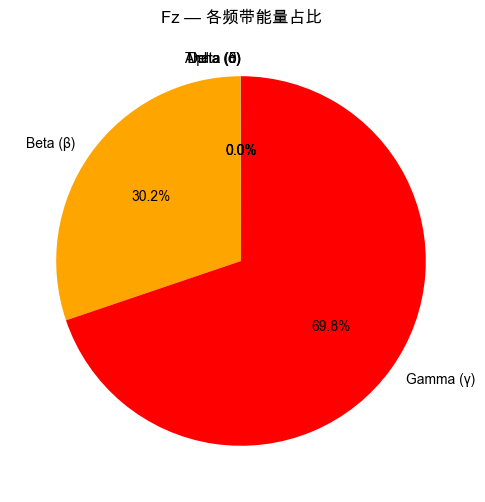

In [64]:
# ===== 方式1: 通过 PSD 逐频带计算（FO7 通道）=====
ch_data = processed_eeg[0, :]

band_ranges = [
    ("Delta (δ)", 0.5, 4),
    ("Theta (θ)", 4, 8),
    ("Alpha (α)", 8, 13),
    ("Beta (β)",  13, 30),
    ("Gamma (γ)", 30, 50),
]

# 计算 PSD
# 计算一个接近采样率的 2 的幂次方数，用于 FFT 运算
nfft_band = DataFilter.get_nearest_power_of_two(sampling_rate)
psd = DataFilter.get_psd_welch(ch_data, nfft_band, nfft_band // 2, sampling_rate,
                                 WindowOperations.BLACKMAN_HARRIS.value)

amplitude = psd[0]  # shape(nfft/2+1)
freqs = psd[1]  # shape(nfft/2+1)


print(f"Fz 通道频带功率:")
print(f"{'频带':<15} {'功率':<12}")
print("-" * 30)

powers = []
for name, low, high in band_ranges:
    power = DataFilter.get_band_power((amplitude, freqs), low, high)
    powers.append(power)
    print(f"{name:<15} {power:<12.4f}")

total_power = sum(powers)
print(f"{'总计':<15} {total_power:<12.4f}")

# 饼图展示各频带占比
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['purple', 'blue', 'green', 'orange', 'red']
labels = [b[0] for b in band_ranges]
ax.pie(powers, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title('Fz — 各频带能量占比')
plt.show()

In [65]:
# ===== 方式2: get_avg_band_powers 批量计算（推荐）=====
# 取一个时间窗口（比如 4 秒的窗口）
window_size = sampling_rate * 4  # 4秒
if processed_eeg.shape[1] >= window_size:
    eeg_window = processed_eeg[:, :window_size]
else:
    eeg_window = processed_eeg

# 确保内存是行优先
eeg_window = np.ascontiguousarray(eeg_window)

print(f"分析窗口: {window_size} 样本 ({window_size/sampling_rate:.0f} 秒)")

# get_avg_band_powers 一次性计算所有通道的所有频带
# 参数: (data_2d, eeg_channel_indices, sampling_rate, apply_filters)
result = DataFilter.get_avg_band_powers(
    eeg_window, # （n_channels, window_size）
    list(range(len(eeg_channels))),  # 输入通道的本地索引 [0,1,2,...,7]
    sampling_rate,
    True  # 自动应用内部滤波器
)
avg_band_powers = result[0]  # shape(n_bands,)
stddev_band_powers = result[1] # shape(n_bands,)
print(avg_band_powers.shape)
print(stddev_band_powers.shape)


分析窗口: 1000 样本 (4 秒)
(5,)
(5,)



所有通道平均频带功率:
  Delta   : 0.0000 ± 1.5263
  Theta   : 0.0000 ± 1.2151
  Alpha   : 0.0000 ± 1.6258
  Beta    : 0.3717 ± 1.2406
  Gamma   : 0.6283 ± 1.3553


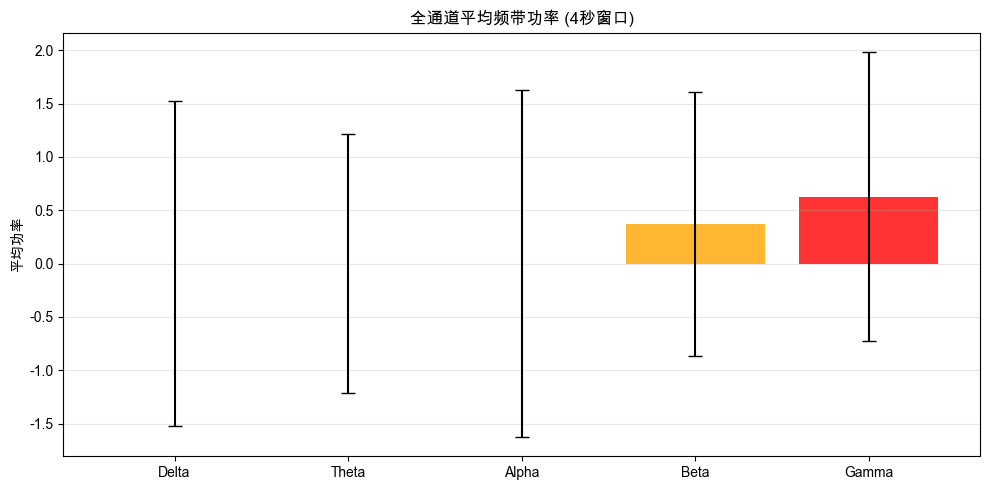

In [68]:
# 结果: (avg_band_powers, stddev_band_powers)
# avg_band_powers[0] = 所有通道 Delta 的平均功率
# avg_band_powers[1] = 所有通道 Theta 的平均功率
# ...等
avg_band_powers = result[0]
stddev_band_powers = result[1]

print(f"\n所有通道平均频带功率:")
band_names = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
for i, name in enumerate(band_names):
    print(f"  {name:<8}: {avg_band_powers[i]:.4f} ± {stddev_band_powers[i]:.4f}")

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(band_names))
bars = ax.bar(x, avg_band_powers, yerr=stddev_band_powers, 
              color=colors, capsize=5, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(band_names)
ax.set_ylabel('平均功率')
ax.set_title('全通道平均频带功率 (4秒窗口)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 5.5 统计特征

除了频带功率，时域统计特征也是重要的信号表征。

In [73]:
import numpy as np  # 确保导入了 numpy

# 计算 Fz 通道的统计特征
ch_data = processed_eeg[0, :]
print(ch_data.shape)

# 使用 numpy 直接计算
mean_val = np.mean(ch_data)
std_val = np.std(ch_data)
rms_val = np.sqrt(np.mean(ch_data**2))  # 均方根（RMS）= 平方后的均值再开方

print(f"Fz 通道统计特征:")
print(f"  均值 (Mean):         {mean_val:.4f} μV")
print(f"  标准差 (Std):        {std_val:.4f} μV")
print(f"  均方根 (RMS):        {rms_val:.4f} μV")

# 所有通道的统计特征
print(f"\n所有通道统计:")
print(f"{'通道':<8} {'均值':<12} {'标准差':<12} {'RMS':<12}")
print("-" * 45)
for i in range(len(eeg_channels)):
    ch_data = processed_eeg[i, :]
    m = np.mean(ch_data)
    s = np.std(ch_data)
    r = np.sqrt(np.mean(ch_data**2))
    print(f"{eeg_names[i]:<8} {m:<12.4f} {s:<12.4f} {r:<12.4f}")

(3752,)
Fz 通道统计特征:
  均值 (Mean):         -0.0001 μV
  标准差 (Std):        0.1205 μV
  均方根 (RMS):        0.1205 μV

所有通道统计:
通道       均值           标准差          RMS         
---------------------------------------------
Fz       -0.0001      0.1205       0.1205      
C3       -0.0001      0.5239       0.5239      
Cz       -0.0010      1.6486       1.6486      
C4       -0.0053      11.9979      11.9979     
Pz       0.0256       48.7318      48.7318     
PO7      0.0273       60.4077      60.4077     
Oz       0.0095       77.0392      77.0392     
PO8      -0.0315      85.6273      85.6273     
F5       -0.0297      74.8814      74.8814     
F7       0.0102       28.7948      28.7948     
F3       -0.0018      35.2049      35.2049     
F1       -0.0182      39.7515      39.7515     
F2       -0.0110      44.9337      44.9337     
F4       -0.0001      49.4630      49.4630     
F6       0.0245       50.5453      50.5453     
F8       0.0234       52.7715      52.7715     


## 5.6 构建特征向量

将时域和频域特征组合成一个特征向量，这是 ML 模型的输入。

### 典型特征向量结构

```
[ch1_delta, ch1_theta, ch1_alpha, ch1_beta, ch1_gamma,  # 通道1频带功率
 ch2_delta, ch2_theta, ch2_alpha, ch2_beta, ch2_gamma,  # 通道2频带功率
 ...
 ch1_mean, ch1_std, ch1_rms,                            # 通道1统计特征
 ...]
```

In [74]:
def build_feature_vector(eeg_data_2d, sampling_rate, channel_names=None):
    """
    从多通道 EEG 数据构建特征向量。
    
    Args:
        eeg_data_2d: (n_channels, n_samples) 的 EEG 数据数组
        sampling_rate: 采样率 (Hz)
        channel_names: 通道名列表（可选）
    
    Returns:
        feature_vector: 一维特征数组
        feature_labels: 特征标签列表
    """
    n_channels = eeg_data_2d.shape[0]
    feature_vector = []
    feature_labels = []
    
    band_ranges = [
        ("Delta", 0.5, 4),
        ("Theta", 4, 8),
        ("Alpha", 8, 13),
        ("Beta", 13, 30),
        ("Gamma", 30, 50),
    ]
    
    for ch_idx in range(n_channels):
        ch_name = channel_names[ch_idx] if channel_names else f"Ch{ch_idx+1}"
        ch_data = eeg_data_2d[ch_idx, :]
        
        # 计算 PSD（每个通道一次）
        nfft = DataFilter.get_nearest_power_of_two(sampling_rate)
        psd = DataFilter.get_psd_welch(ch_data, nfft, nfft // 2, sampling_rate,
                                         WindowOperations.BLACKMAN_HARRIS.value)
        
        # 从 PSD 提取频带功率特征
        for band_name, low, high in band_ranges:
            power = DataFilter.get_band_power(psd, low, high)
            feature_vector.append(power)
            feature_labels.append(f"{ch_name}_{band_name}")
        
        # 统计特征
        mean_val = np.mean(ch_data)
        std_val = np.std(ch_data)
        rms_val = np.sqrt(np.mean(ch_data**2))
        
        feature_vector.extend([mean_val, std_val, rms_val]) # 拆开后单独添加
        feature_labels.extend([f"{ch_name}_Mean", f"{ch_name}_Std", f"{ch_name}_RMS"])
    
    return np.array(feature_vector, dtype=np.float64), feature_labels

# 构建特征向量
feature_vector, feature_labels = build_feature_vector(
    processed_eeg, sampling_rate, eeg_names
)

print(f"特征向量长度: {len(feature_vector)}")
print(f"特征构成: {len(eeg_channels)} 通道 × (5 频带 + 3 统计) = {len(eeg_channels) * 8} 维")
print(f"\n特征预览:")
for i in range(0, min(len(feature_labels), 16)):
    print(f"  {feature_labels[i]:<20} = {feature_vector[i]:.4f}")

特征向量长度: 128
特征构成: 16 通道 × (5 频带 + 3 统计) = 128 维

特征预览:
  Fz_Delta             = 0.0000
  Fz_Theta             = 0.0000
  Fz_Alpha             = 0.0000
  Fz_Beta              = 0.0011
  Fz_Gamma             = 0.0026
  Fz_Mean              = -0.0001
  Fz_Std               = 0.1205
  Fz_RMS               = 0.1205
  C3_Delta             = 0.0000
  C3_Theta             = 0.0002
  C3_Alpha             = 0.0019
  C3_Beta              = 0.0260
  C3_Gamma             = 0.0417
  C3_Mean              = -0.0001
  C3_Std               = 0.5239
  C3_RMS               = 0.5239


## 5.7 滑动窗口特征提取

在实时 BCI 中，需要在滑动窗口上持续提取特征。这是时间动态分析的基础。

In [ ]:
def sliding_window_features(eeg_data_2d, sampling_rate, window_sec=2, step_sec=0.5):
    """
    滑动窗口特征提取。
    
    Args:
        eeg_data_2d: (n_channels, n_samples)
        sampling_rate: 采样率
        window_sec: 窗口大小（秒）
        step_sec: 步长（秒）
    
    Returns:
        features_2d: (n_windows, n_features)
        timestamps: 每个窗口的中心时间索引
    """
    window_samples = int(window_sec * sampling_rate) # 窗口样本数
    step_samples = int(step_sec * sampling_rate) # 步长样本数
    n_total = eeg_data_2d.shape[1] # 总样本数
    
    all_features = []
    all_timestamps = []
    
    for start in range(0, n_total - window_samples, step_samples):
        end = start + window_samples
        window_data = eeg_data_2d[:, start:end]
        
        # 对窗口内每个通道计算 PSD 后提取频带功率
        window_features = []
        nfft = DataFilter.get_nearest_power_of_two(sampling_rate)
        for ch_idx in range(window_data.shape[0]):
            ch_data = window_data[ch_idx, :]
            psd = DataFilter.get_psd_welch(ch_data, nfft, nfft // 2, sampling_rate,
                                             WindowOperations.BLACKMAN_HARRIS.value)
            alpha_power = DataFilter.get_band_power(psd, 8.0, 13.0)
            beta_power = DataFilter.get_band_power(psd, 13.0, 30.0)
            window_features.extend([alpha_power, beta_power])
        
        all_features.append(window_features)
        all_timestamps.append(start + window_samples // 2) # 窗口中心点索引
    return np.array(all_features), np.array(all_timestamps)

# 演示滑动窗口
window_features, window_times = sliding_window_features(
    processed_eeg, sampling_rate, window_sec=2, step_sec=0.5
)
print(window_features.shape)
print(window_times.shape)
print(f"窗口数: {window_features.shape[0]}")
print(f"每窗口特征数: {window_features.shape[1]}")


(27, 32)
(27,)
窗口数: 27
每窗口特征数: 32


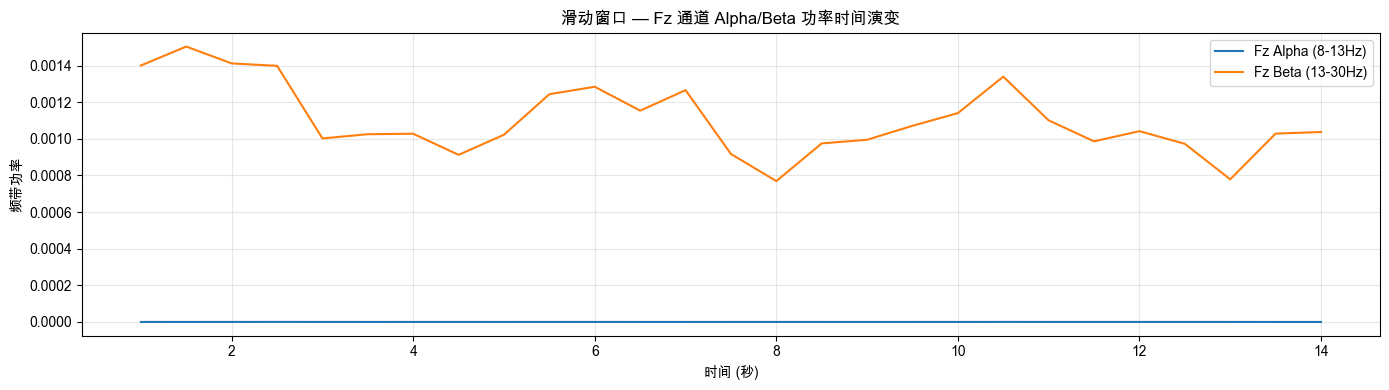

In [86]:
# 可视化 Fz 通道的 Alpha 功率随时间变化
fz_alpha_idx = 0  # 第一个通道的第一个频带就是 Fz Alpha
fz_beta_idx = 1   # Fz Beta

fig, ax = plt.subplots(figsize=(14, 4))
time_axis = window_times / sampling_rate # 窗口中心点索引->时间
ax.plot(time_axis, window_features[:, fz_alpha_idx], label='Fz Alpha (8-13Hz)', linewidth=1.5)
ax.plot(time_axis, window_features[:, fz_beta_idx], label='Fz Beta (13-30Hz)', linewidth=1.5)
ax.set_xlabel('时间 (秒)')
ax.set_ylabel('频带功率')
ax.set_title('滑动窗口 — Fz 通道 Alpha/Beta 功率时间演变')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.8 时间-频率热力图

一种直观展示频域特征随时间演变的方式。

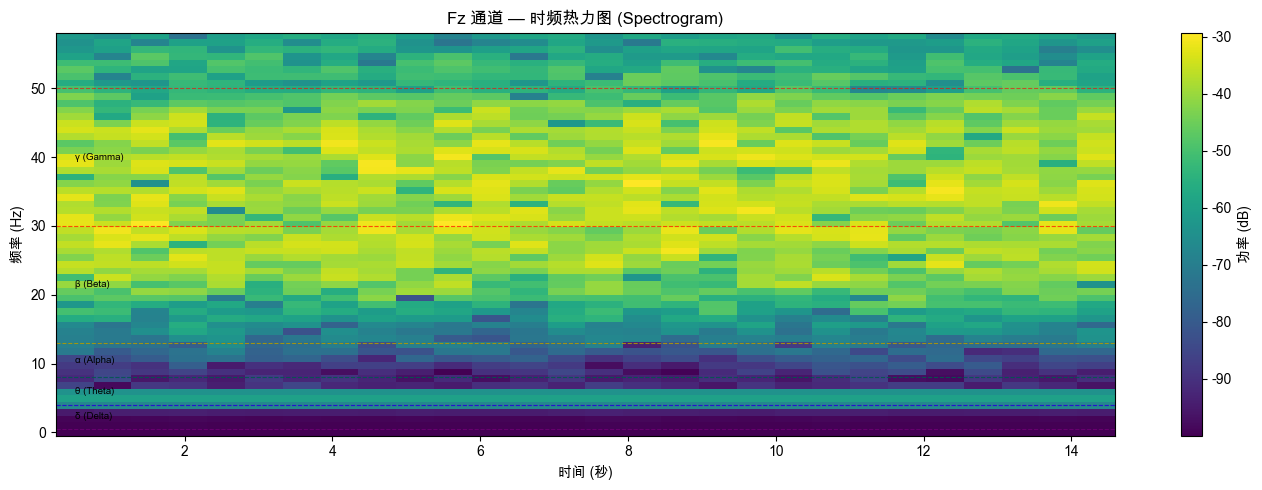

In [90]:
# 为 Fz 通道构建时间-频率热力图
fz_data = processed_eeg[0, :]

nfft = 256
noverlap = nfft // 2
step = nfft - noverlap

spectrogram = []
time_positions = []

for start in range(0, len(fz_data) - nfft, step):
    segment = fz_data[start:start + nfft]
    ampl, freq = DataFilter.get_psd_welch(
        segment, nfft, nfft // 2, sampling_rate,
        WindowOperations.HANNING.value
    )
    spectrogram.append(ampl[:60])  # 只保留 0-60 Hz
    time_positions.append((start + nfft // 2) / sampling_rate) # 窗口中心点索引->时间

spectrogram = np.array(spectrogram).T  # (freq, time)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.pcolormesh(
    time_positions,  # 时间位置（秒），对应热力图的x轴（第一维）
    freq[:60],  # 频率轴（0-60 Hz），对应热力图的y轴（第二维）
    10 * np.log10(spectrogram + 1e-10),  # 功率谱密度，转换为dB尺度，添加极小值避免log(0) （第三维）
    shading='auto',  # 自动选择着色方式
    cmap='viridis'  # 使用viridis颜色映射
)
ax.set_xlabel('时间 (秒)')
ax.set_ylabel('频率 (Hz)')
ax.set_title('Fz 通道 — 时频热力图 (Spectrogram)')
fig.colorbar(im, ax=ax, label='功率 (dB)')

# 标注频带
for low, high, name, color in bands:
    ax.axhline(y=low, color=color, linestyle='--', alpha=0.6, linewidth=0.8)
    ax.axhline(y=high, color=color, linestyle='--', alpha=0.6, linewidth=0.8)
    ax.text(time_positions[0], (low + high) / 2, name, fontsize=7,
            va='center', ha='left', fontweight='bold')

plt.tight_layout()
plt.show()

## 小结

### 特征提取速查

| 类别 | 方法 | 说明 |
|------|------|------|
| PSD | `get_psd_welch(data, nfft, overlap, sr, window)` | 功率谱密度 |
| 单频带功率 | `get_psd_welch()` + `get_band_power()` | PSD → 频带功率 |
| 多频带功率 | `get_avg_band_powers(data, channels, sr, filters)` | 所有通道×所有频带 |
| 滑动窗口 | 自定义循环 | 实时特征提取 |

### 典型特征向量

**8 通道 × (5 频带 + 3 统计) = 64 维特征向量**

→ [Unit 6: ML 集成](unit6_ml_integration.ipynb) — 使用 BrainFlow 内置 ML 模型进行心理状态评估